In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent
sys.path.append(str(project_root / 'src'))

from env import *
from agents.train_a2c import train_a2c, A2CConfig
from agents.experiment import Experiment

In [2]:
df_train = pd.read_csv('../data/raw/binance_BTCUSDT_1h_2021.csv')
df_test = pd.read_csv('../data/raw/binance_BTCUSDT_1h_2022.csv')

df_train.head()

,open,high,low,close,volume
0,28923.63,29031.34,28690.17,28995.13,2311.811445
1,28995.13,29470.00,28960.35,29409.99,5403.068471
2,29410.00,29465.26,29120.03,29194.65,2384.231560
3,29195.25,29367.00,29150.02,29278.40,1461.345077
4,29278.41,29395.00,29029.40,29220.31,2038.046803


In [3]:
# env_train = MyTradingEnv(df_train, window_size=10, max_steps=2500)
# env_train = SharpeReward(df_train, window_size=10, max_steps=2500)
# env_train = ReturnReward(df_train, window_size=10, max_steps=2500)
env_train = DrawdownAwareReward(df_train, window_size=10, max_steps=2500)
env_train.clear_history()
config = A2CConfig(total_timesteps=30_000)

exp = Experiment("a2c-drawdown")
result = train_a2c(env_train, config, exp)
result['model']

Using cpu device
Logging to /home/twisted/Code/ml/DeepRLTradingResearch/experiments/a2c-drawdown/20260331-130609-86eb65
------------------------------------
| time/                 |          |
|    fps                | 511      |
|    iterations         | 100      |
|    time_elapsed       | 0        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -1.07    |
|    explained_variance | -0.0141  |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | -18.1    |
|    value_loss         | 597      |
------------------------------------
------------------------------------
| time/                 |          |
|    fps                | 380      |
|    iterations         | 200      |
|    time_elapsed       | 2        |
|    total_timesteps    | 1000     |
| train/                |          |
|    entropy_loss       | -1.06    |
|    explained_variance | 0.00262  |
|    learning_rate      | 0.0

In [4]:
import seaborn as sns

sns.set_theme(style='whitegrid')

train_steps = env_train.get_steps_df()
train_steps.head()

,episode,step,df_index,action,reward,terminated,truncated,portfolio_value,cash,position,units,entry_price,position_value,holding_time,current_price,n_trades,last_exit_reason,unrealized_pnl
0,1,1,870,0,0.000000,False,False,1000.000000,1.000000e+03,0,0.000000,0.00000,0.000000,0,39267.47,0,None,0.000000
1,1,2,871,1,-0.599700,False,False,999.400300,2.273182e-14,1,0.025392,39378.79956,999.400300,0,39359.12,0,None,-0.499700
2,1,3,872,1,1.673322,False,False,1001.073622,2.273182e-14,1,0.025392,39378.79956,1001.073622,1,39425.02,0,None,1.173622
3,1,4,873,0,11.753627,False,False,1012.827249,2.273182e-14,1,0.025392,39378.79956,1012.827249,2,39887.91,0,None,12.927249
4,1,5,874,2,2.202052,False,False,1015.029300,1.015029e+03,0,0.000000,0.00000,0.000000,0,39998.63,1,agent,0.000000


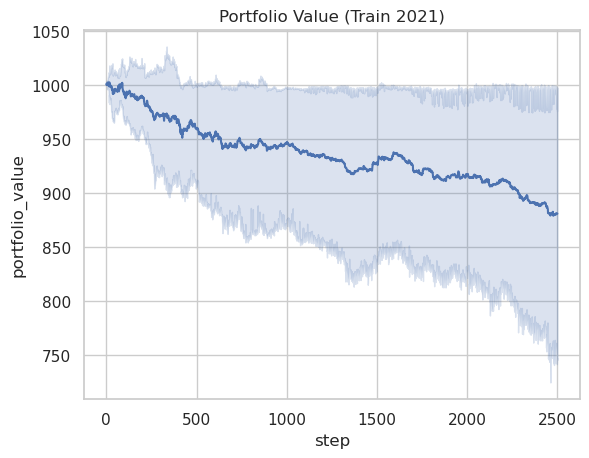

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

sns.lineplot(data=train_steps, x='step', y='portfolio_value')
plt.title('Portfolio Value (Train 2021)')
plt.show()
